# https://velog.io/@hyungraelee/Titanic-with-EDA

In [91]:
!pip install missingno

In [92]:
# !wget -O NanumGothic.ttf \
# https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf

import os

if not os.path.exists("/content/NanumGothic.ttf"):
    !wget -O /content/NanumGothic.ttf \
    https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 등록
font_path = "/content/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(
    fname=font_path
).get_name()

plt.rc("font", family=font_name)

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# plt.rc('font', family='Malgun Gothic')
# plt.rc('axes', unicode_minus=False)

import warnings
warnings.filterwarnings(action='ignore') 

### 1. 데이터 수집
from google.colab import drive
drive.mount('/content/drive')

df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/titanic/train.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
# 분석 목적
# 생존 여부에 여부에 영향을 미친 주요 요인에 대한 체계적 분석

Column	Definition
PassengerId	승객 번호
Survived	생존 여부
Pclass	Ticket class (1:Upper, 2:Middle, 3:Lower)
Name	승객 이름
Sex	성
Age	나이
SibSp	배에 같이 탄 형제 및 배우자 수
Parch	배에 같이 탄 부모 및 아이들 수
Ticket	티켓 번호
Fare	지불 요금
Cabin	선실
Embarked	승선한 항구(C:Cherbourg, Q:Queenstown, S=Southampton)

In [95]:
# 2. 전처리
#    i) 구조진단
df_train.info()
df_train.head(100)
df_train.shape  #(891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

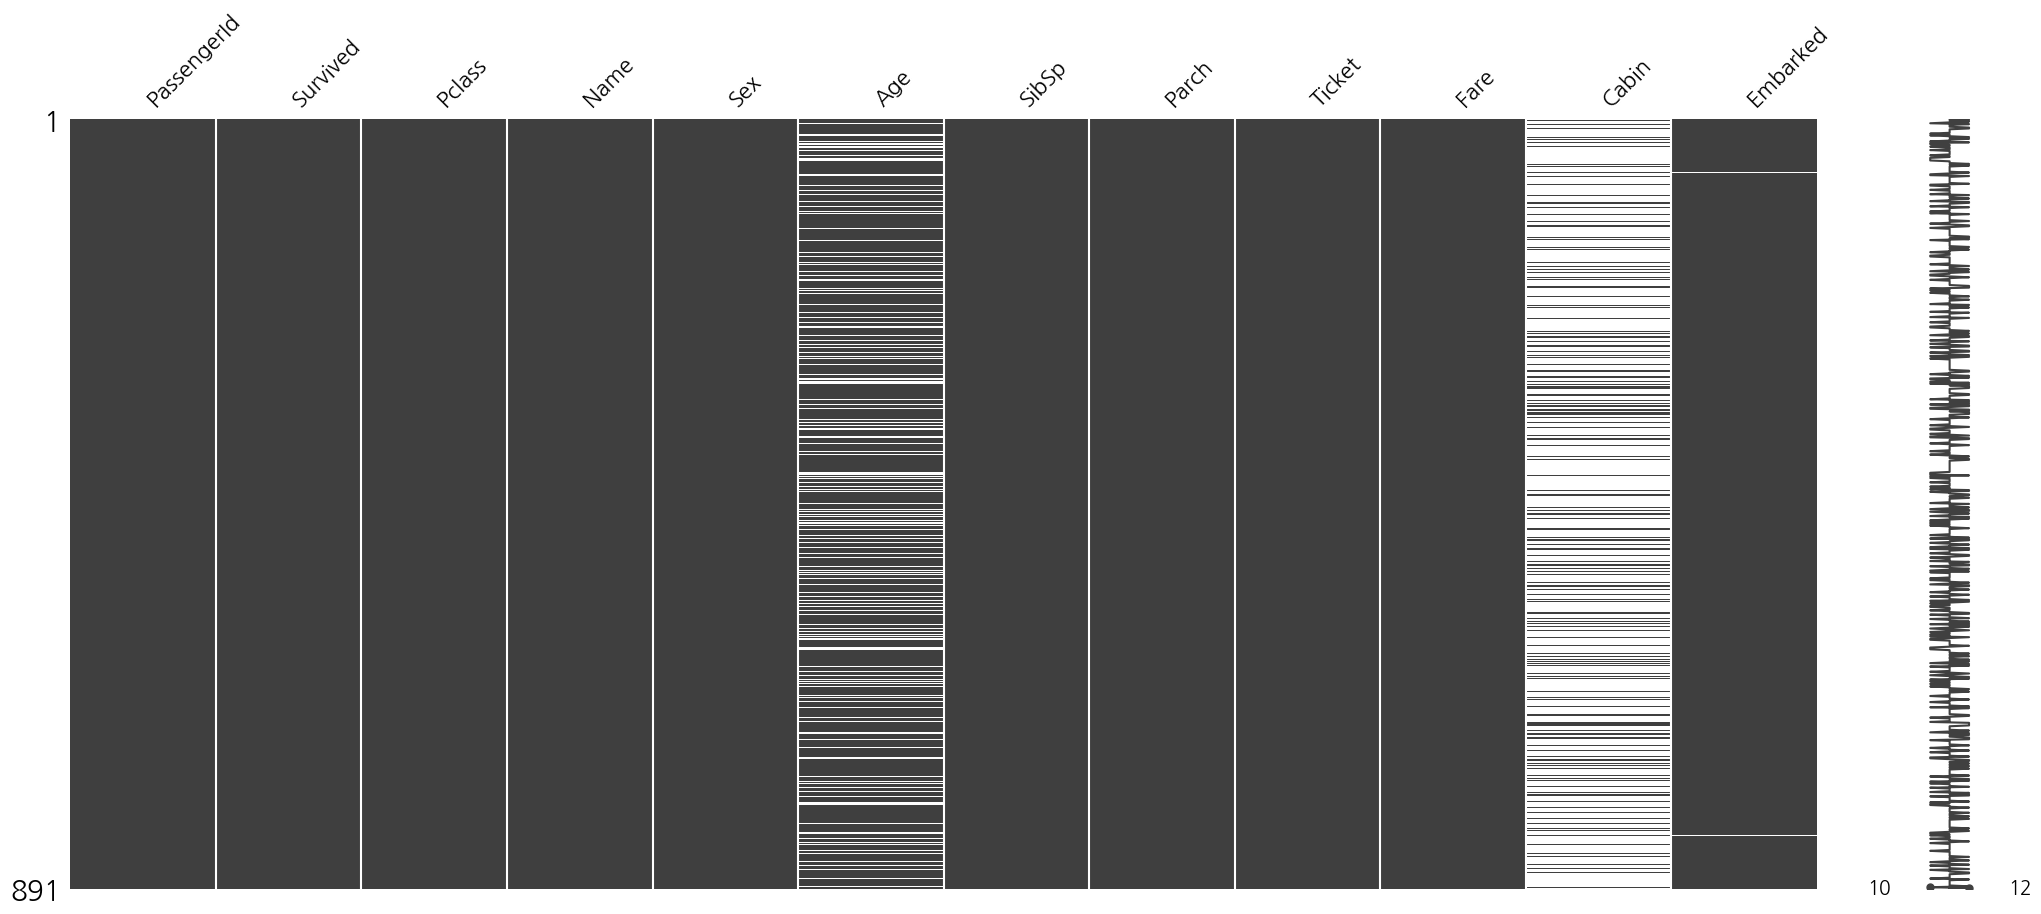

In [96]:
#    ii) 정제 (결측치, 이상치)
df_train.isnull().sum()
msno.matrix(df_train) 

df_train["Age"]=df_train["Age"].fillna(df_train["Age"].median())

df_train["Embarked"]=df_train["Embarked"].fillna(
    df_train["Embarked"].mode()[0]
)

df_train.drop(
    columns=["Cabin"],
    errors="ignore",
    inplace=True
)

#머신러닝 목적이면 결측치 이상치 처리 필요

# 판단:

# Age → 중앙값 대체
# Cabin → 결측 과다 제거
# Embarked → 최빈값

# ① Age → 중앙값(median) 대체
# 판단 1: 결측이 너무 많지 않음

# 20%면 버리기 아까움.
# 891 → 714행

# 손실 큼
# 그래서 채우는 방향.
# 판단 2: 숫자형 변수
# Age는 연속형 데이터

# 10
# 22
# 35
# 80

# 숫자는 보통

# 평균
# 중앙값
# 예측모델

# 사용.
# 판단 3: 분포가 약간 치우침
# 확인

# df["Age"].skew()

# 예시
# 0.38
# → 약한 우측 왜도 => 왜도가 있다는 말은 10, 20, 30, 40, 300 왼쪽으로 끌리는 데이터가 있다는말 임
# 평균보다 중앙값 안정.

# 왜도와 첨도의 이해

# | 항목   | 왜도 (Skewness)   | 첨도 (Kurtosis)       |
# | ----  | ---------------   | -------------------- |
# | 질문   | 데이터가 한쪽으로 치우쳤나? | 데이터가 뾰족하거나 꼬리가 두꺼운가? |
# | 보는 것 | 좌우 비대칭         | 중심 집중 + 꼬리 두께        |
# | 관심   | 방향                | 극단값(이상치)             |
# | 기준값  | 0                 | 0 (초과첨도 기준)          |
# | 영향   | 평균 이동           | 이상치 증가               |


# ② Cabin → 제거(drop)

# 결측

# 687 / 891
# ≈ 77%
# 판단 1: 결측 비율 매우 큼

# 기준(실무에서 많이 씀)

# 결측률	판단
# < 10%	대체
# 10~30%	상황 판단
# 30~50%	신중
# >50%	제거 고려

# Cabin:

# 77%

# 너무 큼.

# 판단 2: 채워도 의미 없음
# 판단 3: 행 제거는 더 위험
# 데이터 붕괴.

# ③ Embarked → 최빈값(mode)
# 결측

# 2 / 891
# ≈ 0.2%

# 매우 적음.
# 값 확인
# df["Embarked"].value_counts()
# 예시

# S    644
# C    168
# Q     77

# S가 압도적.
# 판단 1: 범주형 데이터

# Embarked

# S
# C
# Q

# 평균 불가
# 중앙값 불가
# → 최빈값

# 결국 전처리 판단 공식은 이렇게 생각하면 돼요.

# 1. 결측률 얼마인가?
# ↓
# 2. 컬럼 타입이 무엇인가?
# ↓
# 3. 데이터 분포가 어떤가?
# ↓
# 4. 채우면 왜곡되는가?
# ↓
# 5. 제거하면 손실이 큰가?

# Titanic에 적용하면

# Age
# → 숫자형 + 20%
# → 중앙값

# Cabin
# → 77%
# → 컬럼 제거

# Embarked
# → 범주형 + 0.2%
# → 최빈값

In [ ]:
#    iii) 문자열 · 시계열
# | Name                       | Title |
# | -------------------------- | ----- |
# | Braund, Mr. Owen Harris    | Mr    |
# | Cumings, Mrs. John Bradley | Mrs   |
# | Heikkinen, Miss. Laina     | Miss  |

# Braund, Mr. Owen Harris
#          ↑
# 추출 결과
# Mr


# 왜 이렇게 하냐?

# 원래 Name:
# Braund, Mr. Owen Harris
# 정보가 너무 많음
# 하지만
# Mr
# Mrs
# Miss
# Master

df_train["Title"]=(
    df_train["Name"]
    .str.extract(" ([A-Za-z]+)\.")
)
df_train

# 예제) 
# 1. 생존율 분석 (가장 대표적)
# 질문:
# 호칭별 생존율 차이가 있는가?

# df_train.groupby("Title")["Survived"].mean()
# Mr → 생존율 낮음
# Mrs → 높음
# Miss → 높음


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr


In [98]:
#    iv) 정리 · 변환

# 불필요 제거
# 이 부분은 단순히 컬럼 수 줄이기가 아니라,

# 예측에 도움이 되는 정보인가? 중복인가? 식별자인가?
# 를 판단해서 제거

df_train.drop(
["PassengerId","Name","Ticket"],
axis=1,
inplace=True
)

# 근거
# 승객번호 1번이라 생존했나?
# 승객번호 10번이라 사망했나?
# 번호와 생존은 관계 없음.

# 실무 에서는 아래를 제거
# 고유번호
# Primary Key
# ID
# UUID

# ② Name 제거

# 예시

# Braund, Mr. Owen Harris
# Cumings, Mrs. John Bradley

# 문제:
# 이름 종류가 너무 많음.
# 891명인데
# Name 고유값 ≈ 891개
# 거의 전부 다름.

# 모델 입장

# Braund → ?
# Owen → ?

# 의미 없음.

# 하지만 이름 안에 유용한 정보 있음.
# 하지만 이름 안에 유용한 정보 있음.

# 예:

# Mr
# Mrs
# Miss
# Master

# 그래서

# df["Title"] = (
#     df["Name"]
#     .str.extract(
#         " ([A-Za-z]+)\."
#     )
# )

# 만 추출.

# 그 후 제거.

# df.drop(
# "Name",
# axis=1
# )

# 판단 기준

# 고유값 너무 많음
# (High Cardinality)

# ③ Ticket 제거

# 예시

# A/5 21171
# PC 17599
# STON/O2 3101282

# 문제:

# 이게 생존과 직접 연결 안 됨.

# 확인
# df["Ticket"].nunique()
# 결과
# 681
# 891명 중
# 681개 종류
# 너무 많음.

# 컬럼	           제거 이유
# PassengerId	  단순 식별자
# Name	          고유값 과다
# Ticket	        종류 과다 + 의미 약함

df_train



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Rev
887,1,1,female,19.0,0,0,30.0000,S,Miss
888,0,3,female,28.0,1,2,23.4500,S,Miss
889,1,1,male,26.0,0,0,30.0000,C,Mr


In [99]:
# 피처 엔지니어링
# 피처 엔지니어링(Feature Engineering) 은 데이터 분석/머신러닝에서 가장 중요한 단계 중 하나입니다.
# 한 줄 정의부터:
# 기존 데이터를 더 의미 있는 변수(Feature)로 변환하거나 새로 만드는 작업

# 원본 데이터
# ↓
# 모델이 이해하기 쉬운 정보로 가공

# 피처엔지니어링 이해하기

# | 종류    | 예시        |
# | ----- | --------- |
# | 결합    | 키+몸무게→BMI |
# | 분할    | 날짜→연·월·요일 |
# | 구간화   | 나이→연령대    |
# | 문자 추출 | 이름→호칭     |
# | 집계    | 구매금액→평균   |
# | 변환    | 로그 변환     |

# 전처리
# → 데이터를 깨끗하게 만드는 작업

# 피처 엔지니어링
# → 데이터를 똑똑하게 만드는 작업

# (1) FamilySize 생성

# 원본

# SibSp	Parch
# 1	0
# 2	1

# 질문

# 혼자인가?
# 가족이 많은가?

# 생성

# df["FamilySize"] = (
#     df["SibSp"]
#     +
#     df["Parch"]
#     +
#     1
# )

# 결과

# SibSp	Parch	FamilySize
# 1	0	2
# 2	1	4

# 의미

# 탑승 가족 수

#    v) 재구조화
df_train["FamilySize"] = (
    df_train["SibSp"]+
    df_train["Parch"]+1
)

# import pandas as pd

# df = pd.read_csv("train.csv")


# # 가족 수
# df["FamilySize"] = (
#     df["SibSp"]
#     +
#     df["Parch"]
#     +
#     1
# )


# # 혼자 여부
# df["IsAlone"] = (
#     df["FamilySize"] == 1
# ).astype(int)


# # 호칭
# df["Title"] = (
#     df["Name"]
#     .str.extract(
#         " ([A-Za-z]+)\."
#     )
# )


# # 연령대
# df["AgeGroup"] = pd.cut(
#     df["Age"],
#     [0,18,40,60,100]
# )


# # 요금 그룹
# df["FareLevel"] = pd.qcut(
#     df["Fare"],
#     4
# )


# # 티켓 그룹
# df["TicketGroup"] = (
#     df.groupby(
#         "Ticket"
#     )["Ticket"]
#     .transform(
#         "count"
#     )
# )

# print(
#     df[
#         [
#             "FamilySize",
#             "IsAlone",
#             "Title",
#             "AgeGroup",
#             "FareLevel",
#             "TicketGroup"
#         ]
#     ].head()
# )



In [100]:
#    vi) 스케일링
# 1. 스케일링이란?
# 한 줄 정의:
# 서로 다른 크기의 숫자를 비슷한 기준으로 맞추는 것
# 머신러닝 딥러닝 에서 주로 수행
# 데이터 분석시에서 스케일링이 필요 없을수 있음

# | Age |  Fare |
# | --: | ----: |
# |  22 |  7.25 |
# |  38 | 71.28 |
# |  35 | 53.10 |

# 문제:

# Age   → 0~80
# Fare  → 0~500

# 크기 차이가 큼.
# | 모델      | 스케일링 |
# | ------- | ---- |
# | 로지스틱 회귀 | 추천   |
# | KNN     | 필수   |
# | SVM     | 필수   |
# | 신경망     | 추천   |
# | 트리      | 불필요  |
# | 랜덤포레스트  | 불필요  |

In [101]:
#    vii) 정보 조합 · 파생변수
# 피처 엔지니어링(Feature Engineering) 에서 아주 많이 쓰는 구간화(Binning)
df_train["AgeGroup"] = pd.cut(
    df_train["Age"],
    bins=[0,18,40,60,100]
)
# 또는 아래처럼
# df_train["AgeGroup"] = pd.cut(
#     df_train["Age"],
#     bins=[0,18,40,60,100],
#     labels=[
#         "Child",
#         "Adult",
#         "Middle",
#         "Old"
#     ]
# )
df_train



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,AgeGroup
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,"(18, 40]"
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,"(18, 40]"
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,"(18, 40]"
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,"(18, 40]"
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,"(18, 40]"
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Rev,1,"(18, 40]"
887,1,1,female,19.0,0,0,30.0000,S,Miss,1,"(18, 40]"
888,0,3,female,28.0,1,2,23.4500,S,Miss,4,"(18, 40]"
889,1,1,male,26.0,0,0,30.0000,C,Mr,1,"(18, 40]"


In [102]:
#    viii) 그룹기반

#    ix) 범주형 인코딩 (원핫인코딩)
# df_train = pd.get_dummies(
#     df_train,
#     drop_first=True
# )
# 

# 3. EDA (탐색적 데이터 분석)

## 1) 기초통계량 확인
## 2) 단변량 분석

In [103]:
print("\n기초통계량")
print(df_train.describe())


# ① PassengerId
# 평균 : 446
# 최소 : 1
# 최대 : 891

# 해석:

# 승객 번호일 뿐

# 분석 가치 없음.

# → 제거 대상

# df.drop(
# "PassengerId",
# axis=1
# )

# ② Survived (생존)
# 평균 0.383

# 여기 중요합니다.

# 생존 컬럼은

# 0 = 사망
# 1 = 생존

# 이라 평균 자체가 생존 비율입니다.
# 해석:

# 전체 승객 중
# 약 38% 생존
# 약 62% 사망

# ③ Pclass (객실 등급)
# 평균 : 2.31
# 중앙값 : 3

# 객실:

# 1 → 상류층
# 2 → 중산층
# 3 → 일반석

# 해석:

# 평균이 2.3
# 중앙값이 3

# ↓

# 3등석 승객 많음.

# 즉

# 데이터가 하위 객실에 치우침

# ④ Age (나이)
# 평균 : 29.36
# 표준편차 : 13.0

# 최소 : 0.42
# Q1 : 22
# 중앙값 : 28
# Q3 : 35
# 최대 : 80

# 해석:

# 평균
# 평균 승객 나이
# ≈ 29세
# 중앙값
# 절반은
# 28세 이하
# Q1
# 25% 승객
# 22세 이하
# Q3
# 75% 승객
# 35세 이하
# 최대
# 80세 존재

# ↓

# 노인 존재

# 평균

# 29.36

# 중앙값

# 28

# 차이 작음

# ↓

# 큰 왜도 없음
# 약간 우측 치우침

# ⑤ SibSp (형제·배우자 수)
# 평균 : 0.52
# 최대 : 8

# 해석:

# 대부분

# 혼자
# 또는
# 1명 동반

# 많음.

# 하지만

# 최대 8명

# ↓

# 대가족 존재.

# 중앙값

# 0

# ↓

# 절반 이상 혼자 탑승

# ⑥ Parch (부모·자녀 수)
# 평균 : 0.38
# 중앙값 : 0
# 최대 : 6

# 해석:

# 대부분

# 부모·자녀 없이 탑승

# 하지만 일부 가족 승객 있음.

# ⑦ Fare (운임) ← 매우 중요
# 평균 : 32
# 중앙값 : 14

# 최대 : 512

# 이거 보자마자 보이는 것:

# 평균

# 32

# 중앙값

# 14

# 차이 큼.

# ↓

# 오른쪽 꼬리.

# ↓

# 고가 티켓 존재.

# 사분위수

# Q1 = 7
# Q3 = 31

# 해석:

# 50% 승객
# 7~31 요금

# 그런데

# 최대 512

# ↓

# 엄청 비싼 표 있음.

# ↓

# 평균 왜곡 가능.

# ↓

# 중앙값 고려.


기초통계량
         Survived      Pclass         Age       SibSp       Parch        Fare  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208   
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429   
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000   
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400   
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200   
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000   
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200   

       FamilySize  
count  891.000000  
mean     1.904602  
std      1.613459  
min      1.000000  
25%      1.000000  
50%      1.000000  
75%      2.000000  
max     11.000000  


### 기초 통계량 인사이트
```
1. 생존률 약 38%

2. 승객 대부분 3등석

3. 평균 나이 약 29세

4. 절반 이상 가족 없이 탑승

5. 운임(Fare)은 우측 편향 심함
→ 스케일링 고려

6. Age는 큰 이상치 없음
→ 중앙값 대체 적절
```


In [104]:
## 2) 단변량 분석
# 컬럼 하나만 보고 분포·특징·이상치를 이해하는 분석

# 아래의 순서로 진행 해봄
# 1. 생존(Survived)
# 2. 나이(Age)
# 3. 객실등급(Pclass)
# 4. 운임(Fare)

빈도수
Survived
0    549
1    342
Name: count, dtype: int64

비율(%)
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


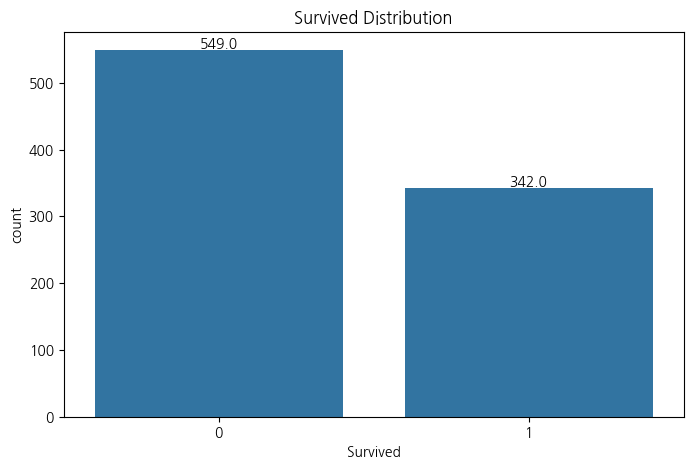

In [105]:
# Survived (생존 여부) 단변량 분석

count = (
    df_train["Survived"]
    .value_counts()
)

# 비율

ratio = (
    df_train["Survived"]
    .value_counts(
        normalize=True
    )
    * 100
)

print("빈도수")
print(count)

print()

print("비율(%)")
print(
    ratio.round(2)
)

plt.figure(
    figsize=(8,5)
)


ax = sns.countplot(
    x="Survived",
    data=df_train
)

# 막대 위 수치 출력

for p in ax.patches:

    height = p.get_height()

    ax.annotate(
        f"{height}",
        (
            p.get_x()
            +
            p.get_width()/2,
            height
        ),
        ha="center",
        va="bottom"
    )


plt.title(
    "Survived Distribution"
)

plt.show()

# 인사이트 도출
#전체 승객의 약 62%가 사망
# 생존률은 약 38%
# 데이터가 사망 쪽으로 약간 치우쳐 있음

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


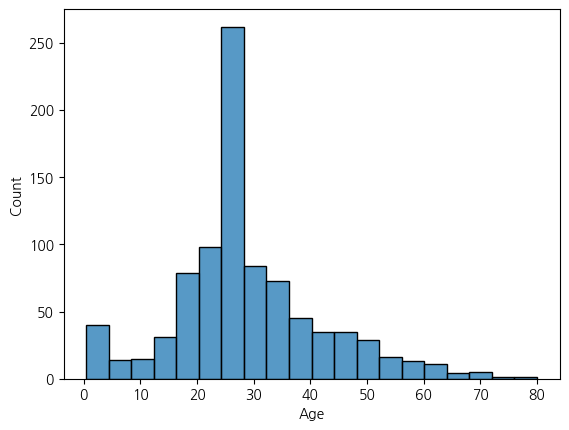

In [106]:
# 2. 나이

print(
df_train["Age"]
.describe()
)
sns.histplot(
df_train["Age"],
bins=20
)

plt.show()

# 20~30세 가장 많음
# 어린아이 존재
# 노인 존재
# 약한 우측 왜도

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    55.11
1    24.24
2    20.65
Name: proportion, dtype: float64


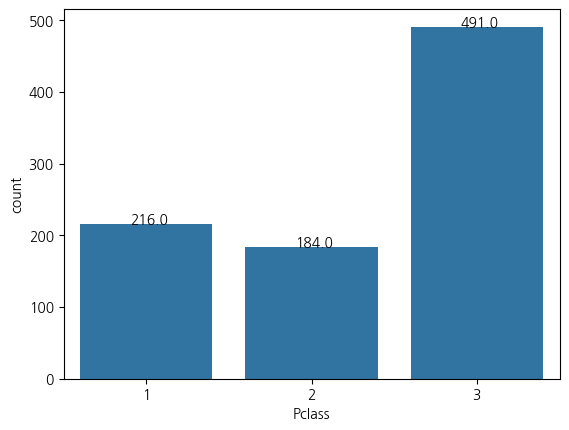

In [107]:
# 3. Pclass (객실 등급)

count=df_train["Pclass"].value_counts()

ratio=(
df_train["Pclass"]
.value_counts(
normalize=True
)
*100
)

print(count)
print(ratio.round(2))

ax=sns.countplot(
x="Pclass",
data=df_train
)

for p in ax.patches:

 ax.annotate(
  p.get_height(),

 (
 p.get_x()+0.3,
 p.get_height()
 )
 )

plt.show()

# 3등석 승객 비율 가장 큼
# 약 55%
# 하위 객실 승객 많음

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


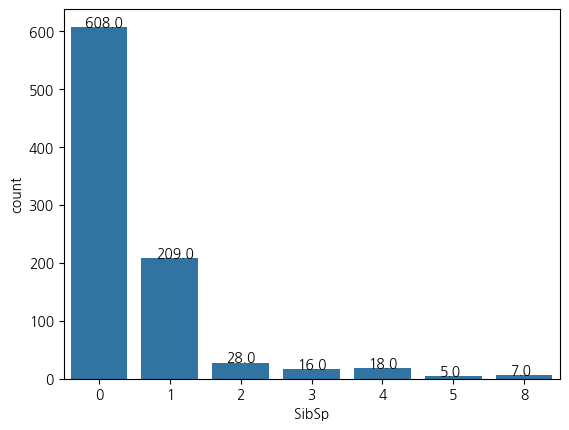

In [108]:
# 4. SibSp (형제·배우자 수)
print(
df_train["SibSp"]
.value_counts()
)

ax=sns.countplot(
x="SibSp",
data=df_train
)

for p in ax.patches:

 ax.annotate(
 p.get_height(),

 (
 p.get_x()+0.2,
 p.get_height()
 )
 )

plt.show()

# 대부분 혼자 탑승
# 일부 가족 탑승

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


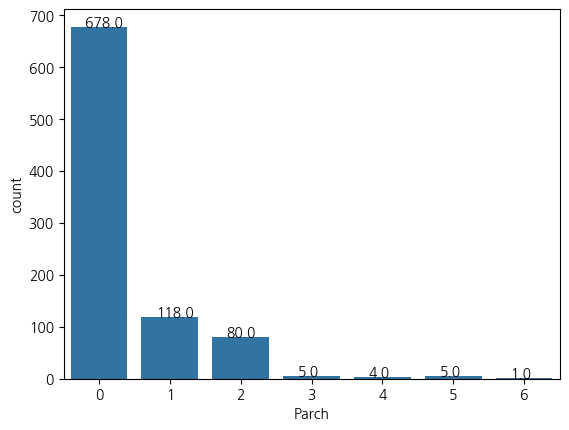

In [109]:
# 5. Parch (부모·자녀 수)
print(
df_train["Parch"]
.value_counts()
)

ax=sns.countplot(
x="Parch",
data=df_train
)

for p in ax.patches:

 ax.annotate(
 p.get_height(),

 (
 p.get_x()+0.2,
 p.get_height()
 )
 )

plt.show()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


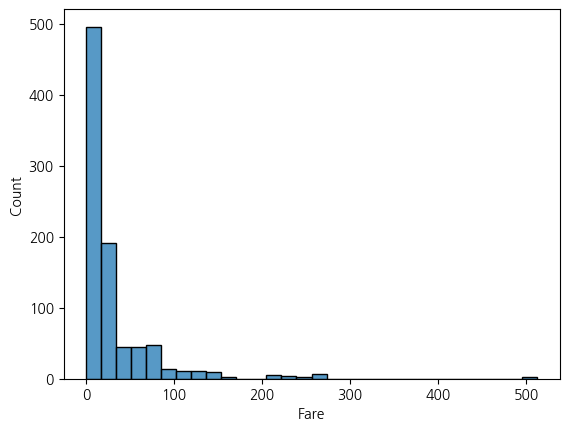

In [110]:
# 6. Fare (운임)
print(
df_train["Fare"]
.describe()
)

sns.histplot(
df_train["Fare"],
bins=30
)

plt.show()

In [111]:
# 3) 이변량

# 이변량 분석은:
# 변수 2개 사이의 관계를 분석하는 것

# ① 수치 확인
# ↓
# ② 시각화
# ↓
# ③ 해석


# 도메인 지식이 있는 경우
# ↓
# 의미 있는 조합 선정
# ↓
# 이변량 분석

# 의미 있는 조합을 먼저 고려
# 1. Sex ↔ Survived
# 2. Pclass ↔ Survived
# 3. Age ↔ Survived
# 4. Fare ↔ Survived
# 5. FamilySize ↔ Survived


# 도메인 지식이 없는 경우
# 전체 변수 상관관계 확인
# ↓
# 관계가 큰 변수 선택
# ↓
# 이변량 분석

# 기초통계량
# ↓
# 단변량 분석
# ↓
# 상관관계 분석 (Heatmap)
# ↓
# 이변량 분석
# ↓
# 다변량 분석

# 실제 분석시는 위의 두 조합을 전부 고려

            Survived    Pclass       Age     SibSp     Parch      Fare  \
Survived    1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307   
Pclass     -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500   
Age        -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688   
SibSp      -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651   
Parch       0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225   
Fare        0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000   
FamilySize  0.016639  0.065997 -0.245619  0.890712  0.783111  0.217138   

            FamilySize  
Survived      0.016639  
Pclass        0.065997  
Age          -0.245619  
SibSp         0.890712  
Parch         0.783111  
Fare          0.217138  
FamilySize    1.000000  


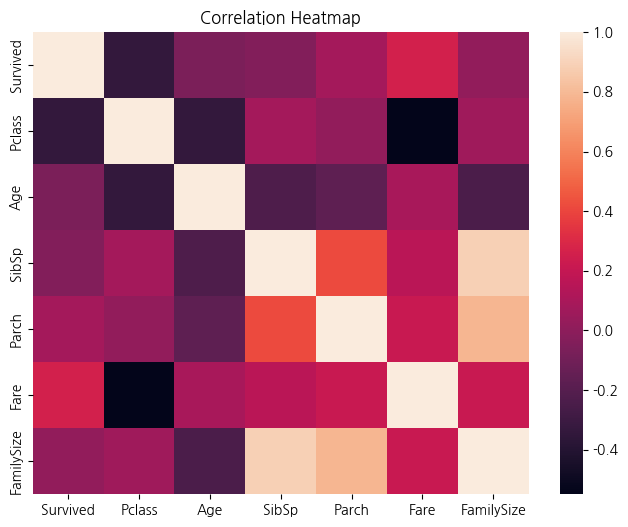

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(
    figsize=(8,6)
)

print(df_train.corr(numeric_only=True))
sns.heatmap(df_train.corr(numeric_only=True))
plt.title(
"Correlation Heatmap"
)
plt.show()

#분석결과
# Pclass     -0.338 ← 가장 큼
# Fare        0.257 ← 의미 있음
# Parch       0.082 ← 약함
# Age        -0.065 ← 약함
# SibSp      -0.035 ← 거의 없음
# FamilySize  0.017 ← 거의 없음

# 이변량 분석 후보 선정
# |corr| ≥ 0.2
# Pclass     -0.338 ← 가장 큼
# Fare        0.257 ← 의미 있음

Survived     0     1
Pclass              
1         37.0  63.0
2         52.7  47.3
3         75.8  24.2
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


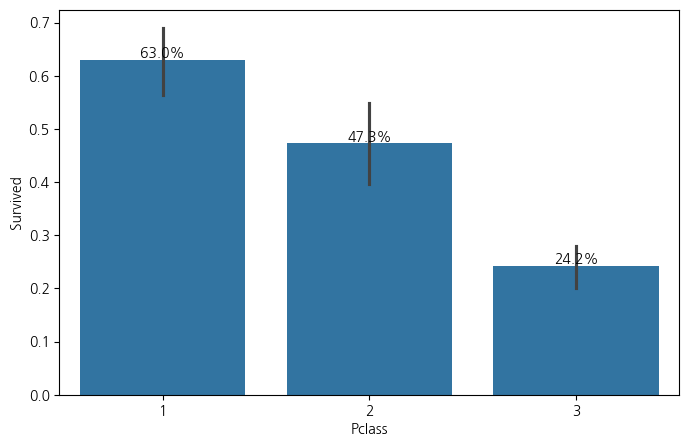

In [113]:
# ① Pclass ↔ Survived

# 질문:

# 객실 등급에 따라 생존률 차이가 있는가?

result = (
    pd.crosstab(
        df_train["Pclass"],
        df_train["Survived"],
        normalize="index"
    ) * 100
)

print(
    result.round(1)
)
#생존률만 보기
survival = (
    df_train
    .groupby("Pclass")
    ["Survived"]
    .mean()
    *100
)

print(
    survival.round(1)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Pclass",
    y="Survived",
    data=df_train
)

for p in ax.patches:

    percent = p.get_height()*100

    ax.annotate(
        f"{percent:.1f}%",
        (
            p.get_x()
            +
            p.get_width()/2,
            p.get_height()
        ),

        ha="center",
        va="bottom"
    )

plt.show()

# 1등석 생존률 63%
# 3등석 생존률 24%
# 객실 등급이 낮아질수록 생존 감소
# Heatmap의 음의 상관(-0.338)이 실제 데이터에서도 확인됨

          count   mean    std  min    25%   50%   75%     max
Survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


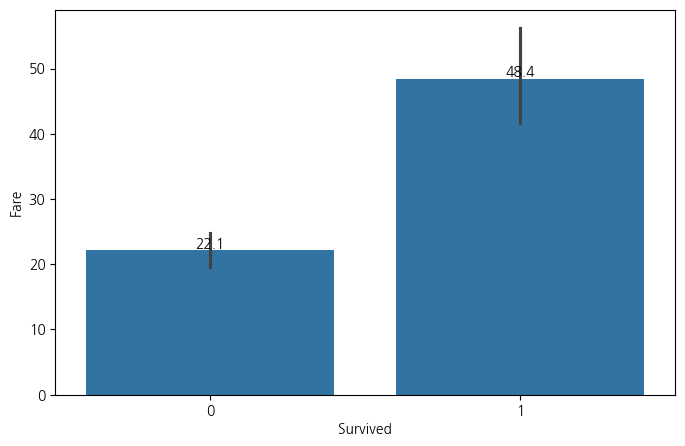

In [114]:
# ② Fare ↔ Survived
# 질문:
# 운임이 높을수록 생존률이 증가하는가?

result = (
    df_train
    .groupby("Survived")
    ["Fare"]
    .describe()
)

print(
    result.round(2)
)

# 사망 평균 요금 : 22
# 생존 평균 요금 : 48

#             mean
# 0          22.12
# 1          48.40
plt.figure(
    figsize=(8,5)
)

ax = sns.barplot(

x="Survived",

y="Fare",

data=df_train

)

for p in ax.patches:
    value = p.get_height()
    ax.annotate(
        f"{value:.1f}",
        (
            p.get_x() + p.get_width()/2,
            value
        ),
        ha="center",
        va="bottom"
    )

plt.show()

# 분석 및 인사이트

# 사망 평균 운임 22
# 생존 평균 운임 48
# 운임이 높은 승객의 생존률이 더 높음
# Heatmap의 양의 상관(0.257)이 실제 데이터에서도 확인됨

In [115]:
# Heatmap
# ↓

# Pclass (-0.338)
# Fare (0.257)

# ↓

# 이변량 검증 완료

# 객실 등급과 운임이
# 생존에 가장 큰 영향을 주는 변수 후보

In [116]:
# 남은 이변량 분석 3개 분석

Survived     0     1
Sex                 
female    25.8  74.2
male      81.1  18.9


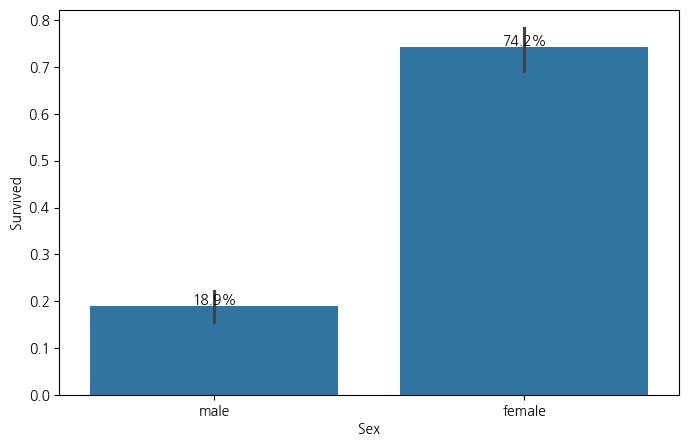

In [117]:
# ③ Sex ↔ Survived
# 질문:
# 성별에 따라 생존률 차이가 있는가?

result = (
    pd.crosstab(
        df_train["Sex"],
        df_train["Survived"],
        normalize="index"
    )
    *100
)

print(
    result.round(1)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x="Sex",
    y="Survived",
    data=df_train
)

for p in ax.patches:
    value = p.get_height()*100
    ax.annotate(
        f"{value:.1f}%",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.show()

# 해석
# 여성 생존률 약 74%
# 남성 생존률 약 19%
# 성별 차이가 매우 큼
# 생존을 설명하는 강력한 변수 후보


          count   mean    std   min   25%   50%   75%   max
Survived                                                   
0         549.0  30.03  12.50  1.00  23.0  28.0  35.0  74.0
1         342.0  28.29  13.76  0.42  21.0  28.0  35.0  80.0


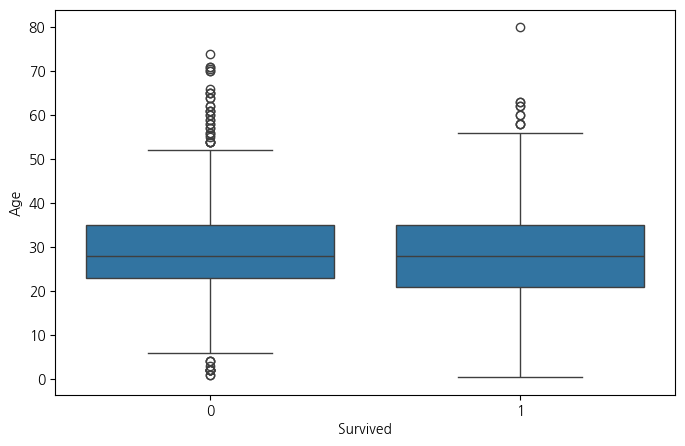

In [118]:
# ④ Age ↔ Survived
# 나이에 따라 생존 차이가 있는가?

result = (
    df_train
    .groupby("Survived")
    ["Age"]
    .describe()
)

print(
    result.round(2)
)

# 사망 평균 나이 : 30.0
# 생존 평균 나이 : 28.3

plt.figure(
    figsize=(8,5)
)

sns.boxplot(
x="Survived",
y="Age",
data=df_train
)

plt.show()

#분석

#생존자 평균 나이가 조금 낮음
#차이는 크지 않음
#나이 단독 영향은 약함


In [119]:
# FamilySize ↔ Survived

df_train["FamilySize"] = (
df_train["SibSp"]
+
df_train["Parch"]
+1
)

FamilySize
1     30.4
2     55.3
3     57.8
4     72.4
5     20.0
6     13.6
7     33.3
8      0.0
11     0.0
Name: Survived, dtype: float64


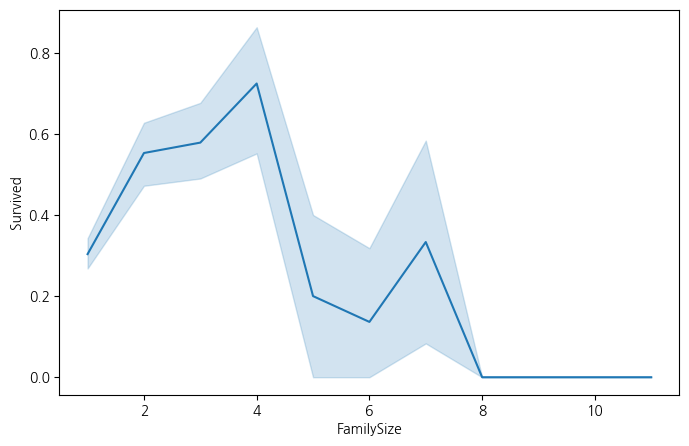

In [120]:
result = (df_train.groupby("FamilySize")["Survived"].mean()*100)
print(result.round(1))

plt.figure(
    figsize=(8,5)
)

ax = sns.lineplot(x="FamilySize",y="Survived",data=df_train)

plt.show()
# 혼자 탑승 시 생존률 낮음
# 2~4명 가족이 높음
# 가족이 너무 많으면 감소

#이변량 분석 결과

| 조합                    | 결론       |
| --------------------- | -------- |
| Sex ↔ Survived        | 매우 강한 차이 |
| Pclass ↔ Survived     | 강한 영향    |
| Age ↔ Survived        | 영향 작음    |
| Fare ↔ Survived       | 양의 관계    |
| FamilySize ↔ Survived | 비선형 관계   |


In [121]:
# 다변량 분석
# 3개 이상의 변수를 동시에 보고 패턴을 찾는 것

# 중요했던 변수들 위주로 조합

# 1. Sex + Pclass → Survived
# 2. Fare + Pclass → Survived
# 3. Age + FamilySize → Survived

Survived          0     1
Sex    Pclass            
female 1        3.2  96.8
       2        7.9  92.1
       3       50.0  50.0
male   1       63.1  36.9
       2       84.3  15.7
       3       86.5  13.5


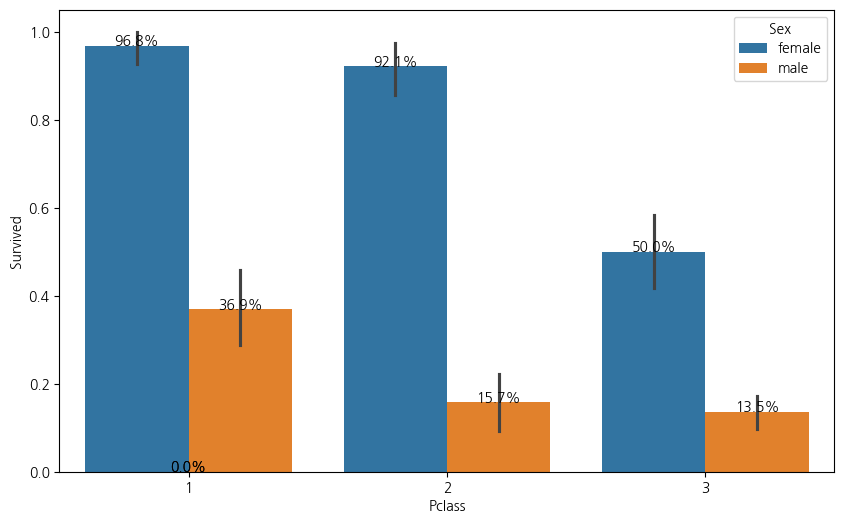

In [122]:
# ① Sex + Pclass → Survived

result = (

pd.crosstab([df_train["Sex"],df_train["Pclass"]],df_train["Survived"],normalize="index")*100)
print(result.round(1))

# Survived

# female 1 → 96.8
# female 2 → 92.1
# female 3 → 50.0

# male 1 → 36.9
# male 2 → 15.7
# male 3 → 13.5

plt.figure(
figsize=(10,6)
)

ax=sns.barplot(
x="Pclass",
y="Survived",
hue="Sex",
data=df_train
)

for p in ax.patches:
 value=p.get_height()*100
 ax.annotate(
 f"{value:.1f}%",
 (
 p.get_x()
 +
 p.get_width()/2,
 p.get_height()
 ),
 ha="center"
 )

plt.show()

# 여성이 모든 객실에서 높음
# 1등석 여성 생존률 압도적
# 남성은 등급 낮을수록 급감
# 성별 효과가 객실보다 강함

Pclass  Survived
1       0           64.7
        1           95.6
2       0           19.4
        1           22.1
3       0           13.7
        1           13.7
Name: Fare, dtype: float64


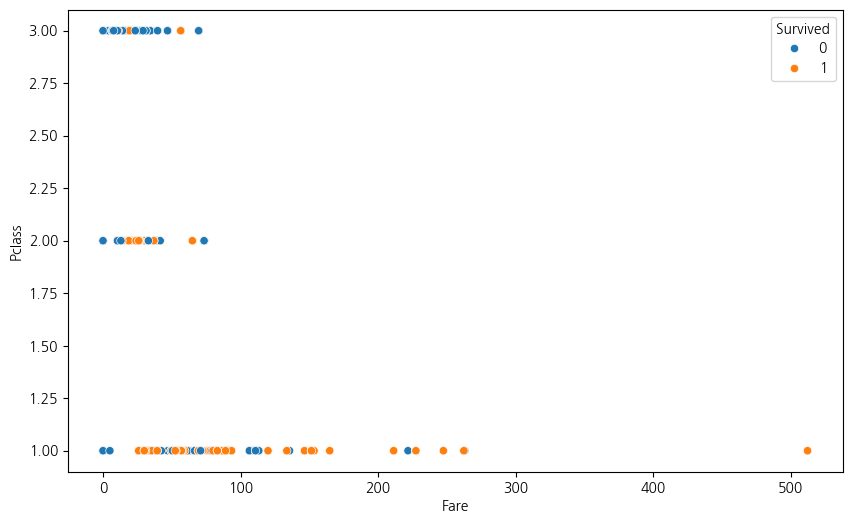

In [123]:
# ② Fare + Pclass → Survived

# 질문:
# 운임과 객실을 같이 보면 생존 패턴이 보이는가?

result = (df_train.groupby(["Pclass","Survived"])["Fare"].mean())

print(result.round(1))

plt.figure(
figsize=(10,6)
)

sns.scatterplot(
x="Fare",
y="Pclass",
hue="Survived",
data=df_train
)

plt.show()

# 해석
# 운임 높음
# ↓

# 상위 객실
# ↓

# 생존 증가

# 운임과 객실 효과 연결됨

# 분석
# 운임이 높을수록 생존률이 증가하는 경향이 나타남
# 이는 높은 운임을 지불한 승객이 주로 상위 객실(1등석)에 탑승했으며, 
# 상위 객실 승객이 구조 과정에서 상대적으로 유리했기 때문으로 해석할 수 있다.

# Fare → Survived (X)

# Fare
#  ↓
# Pclass
#  ↓
# Survived (O)

# 운임 자체보다 객실 등급이 생존을 설명하는 핵심 변수일 가능성이 있다는 점


FamilySize  Survived
1           0           31.2
            1           31.0
2           0           31.6
            1           30.4
3           0           31.3
            1           22.5
4           0           24.1
            1           17.0
5           0           20.7
            1           31.0
6           0           17.6
            1           23.7
7           0           14.9
            1           15.8
8           0           15.7
11          0           28.0
Name: Age, dtype: float64


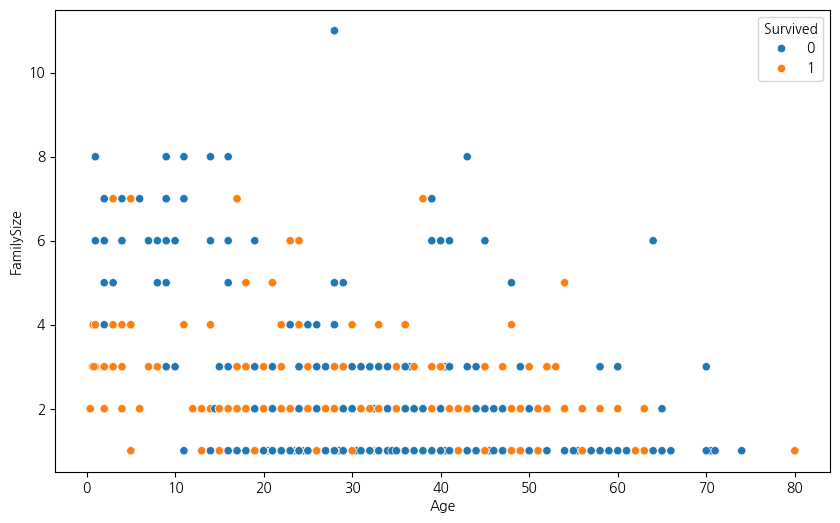

In [124]:
# ③ Age + FamilySize → Survived
# 나이와 가족 규모를 같이 보면 생존 차이가 있는가?
result=(df_train.groupby(["FamilySize","Survived"])["Age"].mean())
print(result.round(1))

plt.figure(
figsize=(10,6)
)

sns.scatterplot(

x="Age",

y="FamilySize",

hue="Survived",

data=df_train

)

plt.show()

# 어린 승객 생존 높음
# 적당한 가족 규모 유리
# 혼자 또는 너무 큰 가족은 감소


# 다변량 분석 최종 결론
# 성별 영향 가장 큼
# 높은 객실 + 높은 운임 유리
# 나이 영향은 상대적으로 약함
# 가족 규모는 적당할 때 생존 증가


In [125]:
# 통계적 가설검정

# EDA
# ↓
# 가설 설정
# ↓
# 통계 검정
# ↓
# p-value 해석
# ↓
# 결론

In [126]:
# 예제 1. 객실 등급(Pclass)이 생존에 영향을 주는가?
# 객실 등급에 따라 생존률 차이가 정말 있는가?
# 아니면 우연인가?

# ① 가설 설정
# 귀무가설(H0)
# 객실 등급과 생존은 관계 없다
# 대립가설(H1)
# 객실 등급과 생존은 관계 있다

# ② 카이제곱 검정 (범주형 × 범주형)
# 사용 이유
# Pclass → 범주형
# Survived → 범주형

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_train["Pclass"],
    df_train["Survived"]
)

print(table)

st,pv,dof,expected = chi2_contingency(table)

print("통계량 :",st)
print("p-value :",pv)

# 객실 등급과 생존은 통계적으로 관계가 있다.

# 즉,
# 1등석·2등석·3등석의 생존 차이는
# 우연으로 보기 어렵다.


Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
통계량 : 102.88898875696056
p-value : 4.549251711298793e-23


In [127]:
# 예제 2. 생존자와 사망자의 평균 운임(Fare)은 차이가 있는가?

# 생존자 운임이 높아 보이는데 진짜 차이가 있는가?

# ① 가설 설정
# 귀무가설(H0)
# 생존자와 사망자의 평균 운임은 같다
# 대립가설(H1)
# 평균 운임이 다르다.

# ② 독립표본 t검정
# Fare → 수치형
# Survived → 그룹

from scipy.stats import ttest_ind

#집단이 다름으로 독립검정
alive = (df_train[df_train["Survived"]==1]["Fare"])
dead = (df_train[df_train["Survived"]==0]["Fare"])

st,pv = ttest_ind(alive,dead,equal_var=False)


print("t값 :",st)
print("p-value :",pv)

# p-value < 0.05
# ↓
# 평균 차이가 존재
# ↓
# 생존자는 사망자보다
# 운임이 높다고 볼 수 있다.


t값 : 6.839099259085254
p-value : 2.6993323503141236e-11


In [128]:
# 예제 3. 나이(Age)는 생존에 영향이 있는가?

# 생존자와 사망자의 나이는 차이가 있는가?

# 생존자와 사망자의 나이의 평균은 같다.(귀무)
# 생존자와 사망자의 나이의 평균은 다르다.(대립)

alive = (df_train[df_train["Survived"]==1]["Age"])
dead = (df_train[df_train["Survived"]==0]["Age"])

st,pv = ttest_ind(alive,dead,equal_var=False)

print(st)
print(pv)

# 결론 귀무가설 기각 못함

# 생존자와 사망자의 평균 나이를 비교한 결과 p-value가 0.058로 나타났다.
# 이는 유의수준 0.05보다 크므로 귀무가설을 기각할 수 없다.
# 따라서 생존 여부에 따른 평균 나이 차이가 통계적으로 유의하다고 보기 어렵다.


-1.8966053920256696
0.058309159977757444


In [129]:
# 3. 세 집단 평균 비교 (ANOVA)

# 1·2·3등석의 평균 운임은 같은가?

# H0:
# 세 그룹 평균 같다

# H1:
# 하나 이상 다르다

from scipy.stats import f_oneway


p1 = (df_train[df_train["Pclass"]==1]["Fare"])

p2 = (df_train[df_train["Pclass"]==2]["Fare"])

p3 = (df_train[df_train["Pclass"]==3]["Fare"])


st,pv = (f_oneway(p1,p2,p3))

print(st)
print(pv)

# p<0.05
# ↓
# 객실별 평균 운임 차이 존재

242.34415651744814
1.0313763209141171e-84


In [130]:
# 4. 정규성 검정 (Shapiro)
# 질문:
# Fare 데이터가 정규분포인가?

In [131]:
# 7. 상관 검정 (Pearson)

# 질문:

# 나이와 운임은 관계 있는가?
# 가설
# H0:
# 상관계수 = 0

# H1:
# 상관 존재

from scipy.stats import pearsonr


st,pv = (pearsonr(df_train["Age"],df_train["Fare"]))


print(st)
print(pv)

0.09668842218036486
0.0038667538638709515
